In [2]:
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn import tree
import pandas as pd
import duckdb as dd

In [ ]:
carpeta = 'Archivos/'
map_caracters =  pd.read_csv(carpeta + 'kuzushiji_full.csv')
class_caracters =  pd.read_csv(carpeta + 'kmnist_classmap_char.csv ')

list_columns =  []
for i in range(784):
    list_columns.append(f'pixel_{i+1}')
list_columns.append('label')
map_caracters.columns = list_columns


X = map_caracters.copy()
for i in range(2):
    img = np.array(X.iloc[i][:-1]).reshape((28,28))
    plt.imshow(img, cmap='gray')
    plt.show()


    

In [4]:
dd.sql(" SELECT DISTINCT label FROM  map_caracters ").df()

,label
0,5
1,9
2,7
3,2
4,1
5,4
6,8
7,6
8,3
9,0


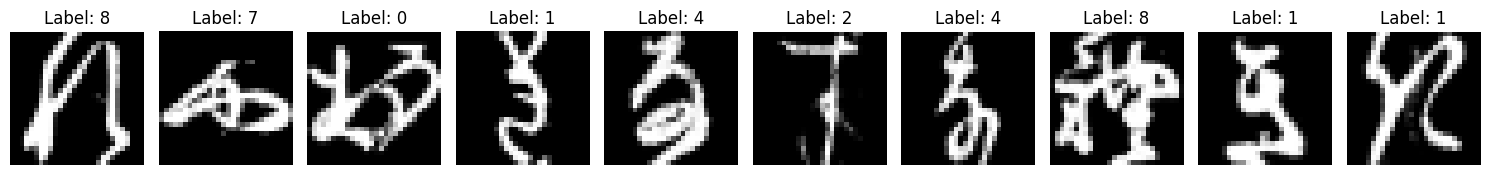

In [18]:
# Visualizar varios caracteres con información adicional
num_ejemplos = 10  # Puedes cambiar este número

fig, axes = plt.subplots(1, num_ejemplos, figsize=(15, 3))

for i in range(num_ejemplos):
    # Obtener imagen y label
    img = np.array(X.iloc[i][:-1]).reshape((28, 28))
    label = X.iloc[i]['label']
    
    # Mostrar imagen
    if num_ejemplos > 1:
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f'Label: {label}')
        axes[i].axis('off')
    else:
        plt.imshow(img, cmap='gray')
        plt.title(f'Label: {label}')
        plt.axis('off')

plt.tight_layout()
plt.show()

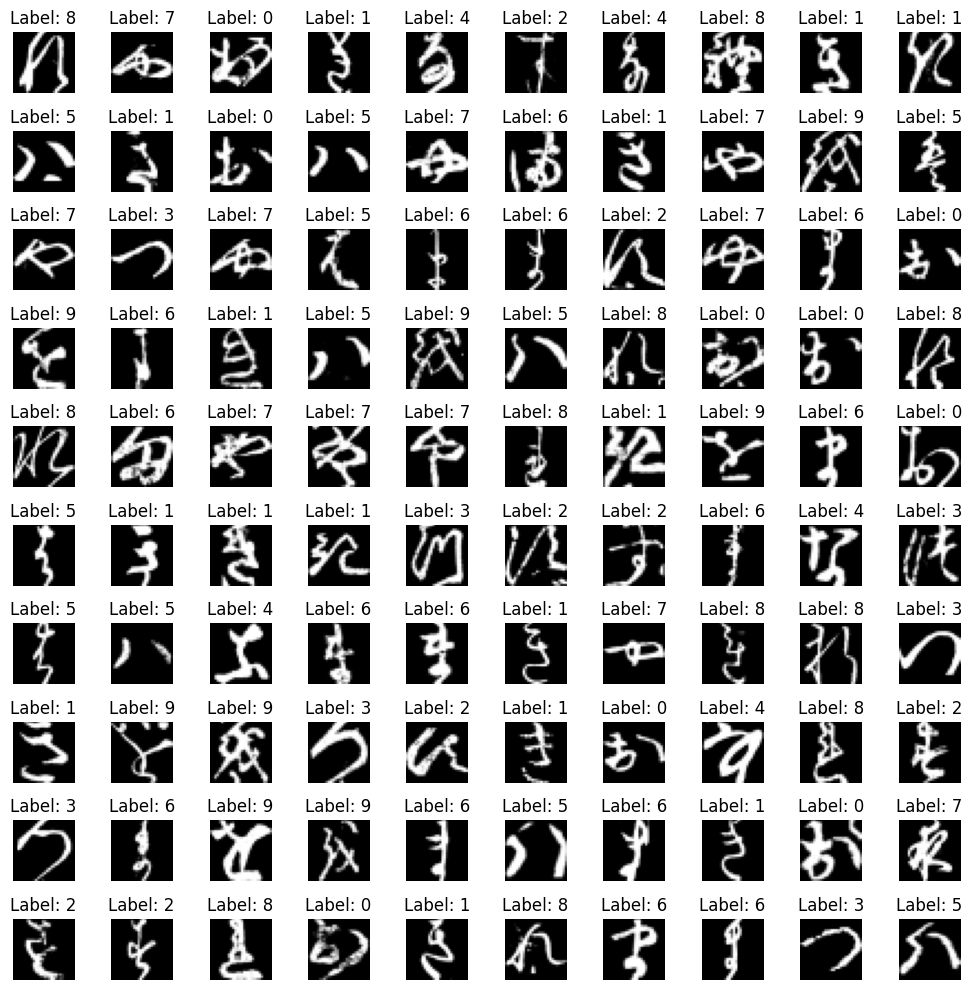

In [21]:
# Visualizar en grid de 3x3
def visualizar_grid(X, filas=3, columnas=3):
    fig, axes = plt.subplots(filas, columnas, figsize=(10, 10))
    
    for i in range(filas * columnas):
        if i < len(X):
            fila = i // columnas
            col = i % columnas
            
            img = np.array(X.iloc[i][:-1]).reshape((28, 28))
            label = X.iloc[i]['label']
            
            axes[fila, col].imshow(img, cmap='gray')
            axes[fila, col].set_title(f'Label: {label}')
            axes[fila, col].axis('off')
    
    plt.tight_layout()
    plt.show()

visualizar_grid(X, 10, 10)

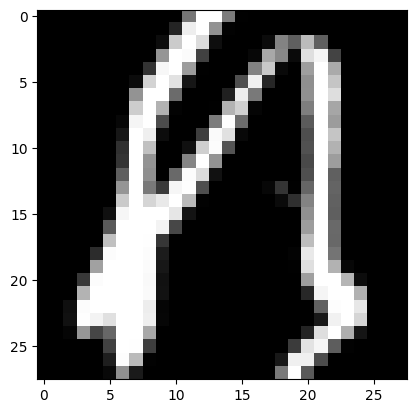

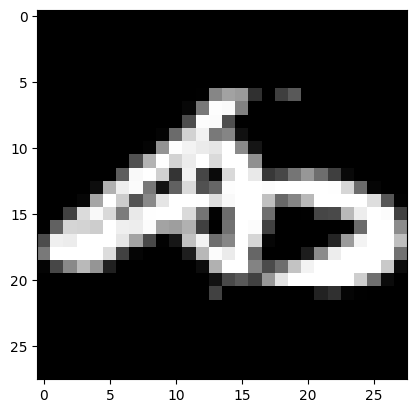

In [15]:
X = map_caracters.copy()
for i in range(2):
    img = np.array(X.iloc[i][:-1]).reshape((28,28))
    plt.imshow(img, cmap='gray')
    plt.show()

In [25]:
X = map_caracters.copy()
y = X['label']
X_pixels = X.drop('label', axis=1)

print("=" * 60)
print("ANÁLISIS EXPLORATORIO - KMNIST DATASET")
print("=" * 60)

# 1. ANÁLISIS BÁSICO DEL DATASET
print("\n1. INFORMACIÓN BÁSICA DEL DATASET")
print(f"• Dimensiones del dataset: {X.shape}")
print(f"• Número de imágenes: {X.shape[0]}")
print(f"• Número de atributos (píxeles): {X_pixels.shape[1]}")
print(f"• Número de clases: {len(y.unique())}")
print(f"• Rango de valores de píxeles: [{X_pixels.min().min()}, {X_pixels.max().max()}]")


ANÁLISIS EXPLORATORIO - KMNIST DATASET

1. INFORMACIÓN BÁSICA DEL DATASET
• Dimensiones del dataset: (70000, 785)
• Número de imágenes: 70000
• Número de atributos (píxeles): 784
• Número de clases: 10
• Rango de valores de píxeles: [0, 255]



2. DISTRIBUCIÓN DE CLASES
label
0    7000
1    7000
2    7000
3    7000
4    7000
5    7000
6    7000
7    7000
8    7000
9    7000
Name: count, dtype: int64


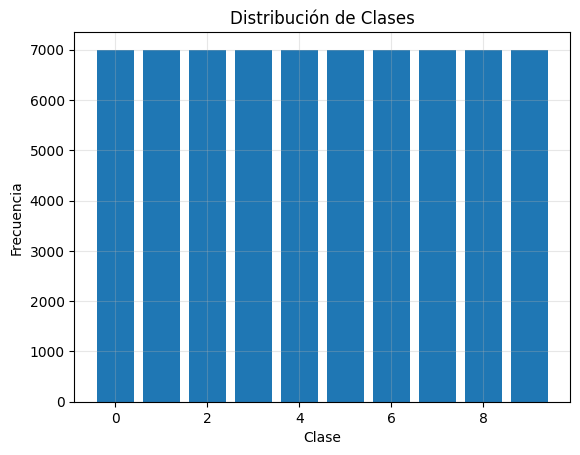

In [29]:
# 2. DISTRIBUCIÓN DE CLASES
print("\n2. DISTRIBUCIÓN DE CLASES")
distribucion_clases = y.value_counts().sort_index()
print(distribucion_clases)



plt.bar(distribucion_clases.index, distribucion_clases.values)
plt.xlabel('Clase')
plt.ylabel('Frecuencia')
plt.title('Distribución de Clases')
plt.grid(True, alpha=0.3)


In [32]:
# 3. ESTADÍSTICAS DESCRIPTIVAS
print("\n3. ESTADÍSTICAS DESCRIPTIVAS")
print(X_pixels.describe())



3. ESTADÍSTICAS DESCRIPTIVAS
            pixel_1       pixel_2       pixel_3       pixel_4       pixel_5  \
count  70000.000000  70000.000000  70000.000000  70000.000000  70000.000000   
mean       0.301243      0.741543      1.249814      2.179300      3.693329   
std        6.156516     10.437733     13.743910     18.550983     24.260307   
min        0.000000      0.000000      0.000000      0.000000      0.000000   
25%        0.000000      0.000000      0.000000      0.000000      0.000000   
50%        0.000000      0.000000      0.000000      0.000000      0.000000   
75%        0.000000      0.000000      0.000000      0.000000      0.000000   
max      255.000000    255.000000    255.000000    255.000000    255.000000   

            pixel_6       pixel_7       pixel_8       pixel_9      pixel_10  \
count  70000.000000  70000.000000  70000.000000  70000.000000  70000.000000   
mean       5.875200      8.773643     12.551114     16.945986     21.871629   
std       30.348452  

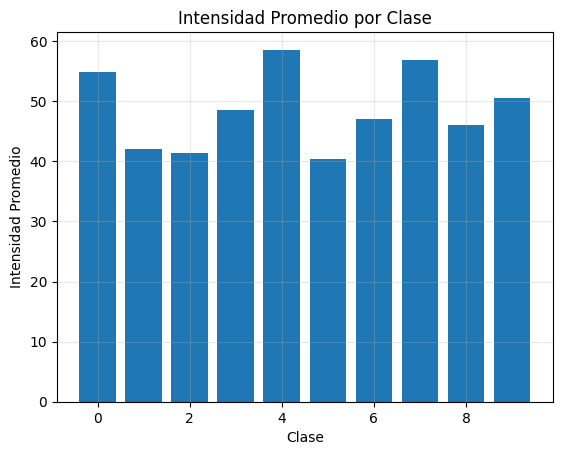

In [37]:
# 4. VISUALIZACIÓN DE CARACTERES POR CLASE

# Promedio de imágenes por clase
promedios_por_clase = []
for clase in sorted(y.unique()):
    mascara = y == clase
    promedio_clase = X_pixels[mascara].mean().values.reshape(28, 28)
    promedios_por_clase.append(promedio_clase.mean())

plt.bar(range(len(promedios_por_clase)), promedios_por_clase)
plt.xlabel('Clase')
plt.ylabel('Intensidad Promedio')
plt.title('Intensidad Promedio por Clase')
plt.grid(True, alpha=0.3)


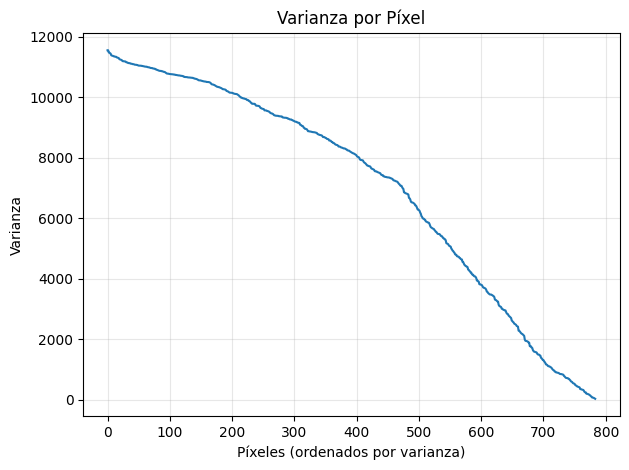

In [36]:

# 5. ANÁLISIS DE VARIANZA POR PÍXEL

varianza_pixels = X_pixels.var().sort_values(ascending=False)
plt.plot(range(len(varianza_pixels)), varianza_pixels.values)
plt.xlabel('Píxeles (ordenados por varianza)')
plt.ylabel('Varianza')
plt.title('Varianza por Píxel')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



7. ANÁLISIS DE SIMILITUD ENTRE CLASES


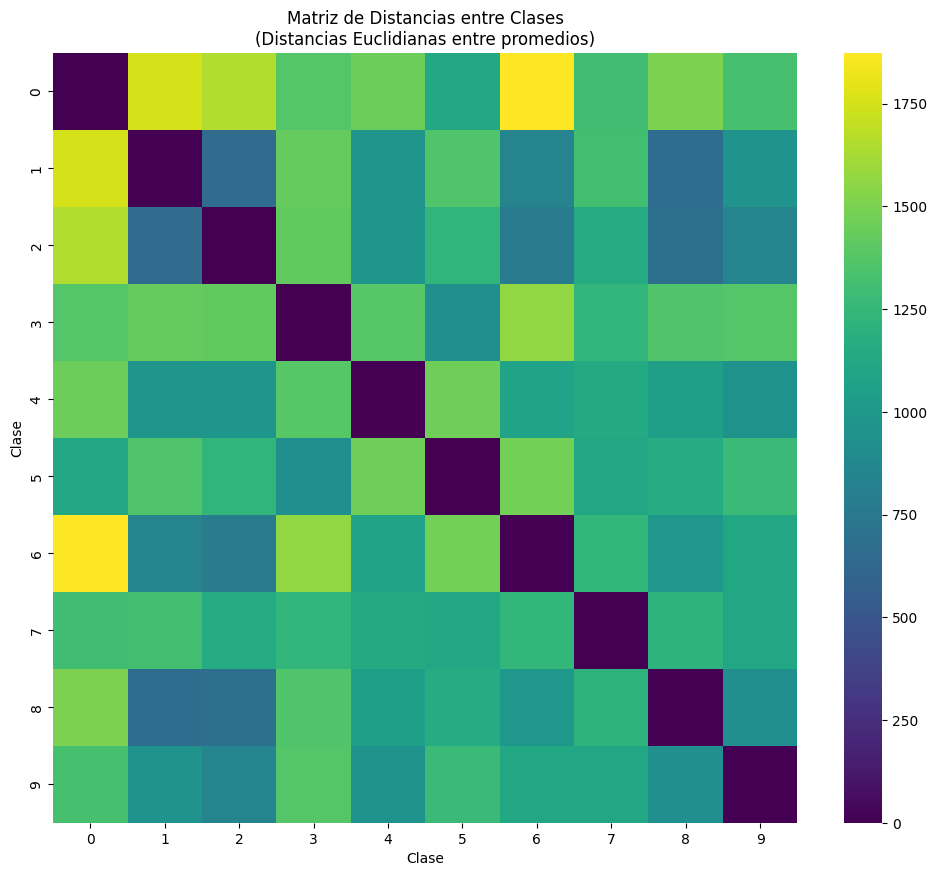

In [41]:
# 7. ANÁLISIS DE SIMILITUD ENTRE CLASES
print("\n7. ANÁLISIS DE SIMILITUD ENTRE CLASES")

# Calcular promedios por clase
promedios_clases = []
for clase in sorted(y.unique()):
    mascara = y == clase
    promedio_clase = X_pixels[mascara].mean().values
    promedios_clases.append(promedio_clase)

promedios_clases = np.array(promedios_clases)

# Matriz de similitud (distancia euclidiana)
from scipy.spatial.distance import pdist, squareform
distancias = squareform(pdist(promedios_clases, 'euclidean'))

plt.figure(figsize=(12, 10))
sns.heatmap(distancias, annot=False, cmap='viridis', 
            xticklabels=range(len(distancias)), 
            yticklabels=range(len(distancias)))
plt.title('Matriz de Distancias entre Clases\n(Distancias Euclidianas entre promedios)')
plt.xlabel('Clase')
plt.ylabel('Clase')
plt.show()


In [42]:
# 8. ANÁLISIS DE CLASE ESPECÍFICA (Clase 8)
print("\n8. ANÁLISIS DE LA CLASE 8")
clase_objetivo = 8
mascara_clase_8 = y == clase_objetivo
X_clase_8 = X_pixels[mascara_clase_8]

print(f"• Número de imágenes en clase 8: {X_clase_8.shape[0]}")
print(f"• Varianza promedio en clase 8: {X_clase_8.var(axis=1).mean():.4f}")


8. ANÁLISIS DE LA CLASE 8
• Número de imágenes en clase 8: 7000
• Varianza promedio en clase 8: 7247.3560


In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [47]:
# 9. ANÁLISIS DE COMPONENTES PRINCIPALES (PCA)
print("\n9. ANÁLISIS PCA - REDUCCIÓN DE DIMENSIONALIDAD")
# Muestreo para no sobrecargar la memoria
muestra_idx = np.random.choice(X_pixels.shape[0], 1000, replace=False)
X_muestra = X_pixels.iloc[muestra_idx]
y_muestra = y.iloc[muestra_idx]



9. ANÁLISIS PCA - REDUCCIÓN DE DIMENSIONALIDAD


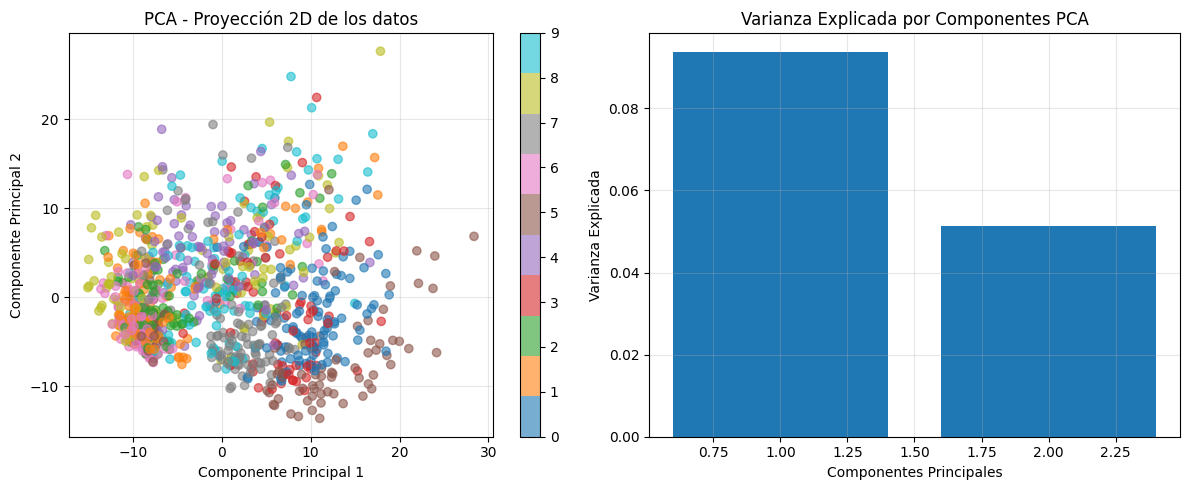

• Varianza explicada por PC1: 0.094
• Varianza explicada por PC2: 0.051
• Varianza total explicada: 0.145


In [48]:
# Aplicar PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(StandardScaler().fit_transform(X_muestra))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_muestra, cmap='tab10', alpha=0.6)
plt.colorbar(scatter)
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('PCA - Proyección 2D de los datos')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
varianza_explicada = pca.explained_variance_ratio_
componentes = range(1, len(varianza_explicada) + 1)
plt.bar(componentes, varianza_explicada)
plt.xlabel('Componentes Principales')
plt.ylabel('Varianza Explicada')
plt.title('Varianza Explicada por Componentes PCA')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"• Varianza explicada por PC1: {varianza_explicada[0]:.3f}")
print(f"• Varianza explicada por PC2: {varianza_explicada[1]:.3f}")
print(f"• Varianza total explicada: {sum(varianza_explicada):.3f}")


CLASIFICACIÓN BINARIA: CLASE 4 vs CLASE 5

a. CONSTRUYENDO SUBCONJUNTO BINARIO
• Total de muestras en subconjunto binario: 14000
• Clase 4 (0): 7000 muestras
• Clase 5 (1): 7000 muestras
• Proporción Clase 4: 0.500
• Proporción Clase 5: 0.500
• Ratio de balance: 1.000
✓ El dataset está balanceado


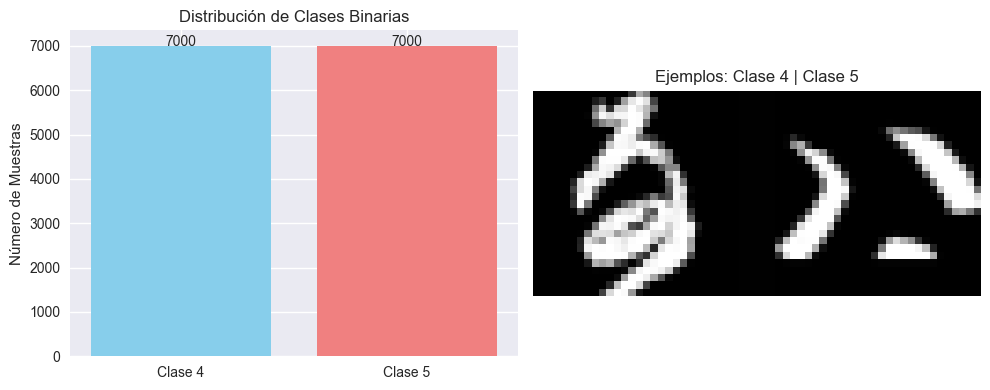


b. SEPARACIÓN EN CONJUNTOS DE TRAIN Y TEST
• Conjunto de entrenamiento: 9800 muestras
• Conjunto de test: 4200 muestras
• Proporción Clase 4 en train: 0.500
• Proporción Clase 5 en train: 0.500

c. SELECCIÓN DE ATRIBUTOS Y MODELADO KNN
• Varianza máxima: 12920.5394
• Varianza mínima: 20.7805
• Varianza promedio: 7259.2719

EVALUANDO CON 3 ATRIBUTOS

Estrategia: alta_varianza
Atributos seleccionados: ['389', '361', '418']

3attrs_alta_varianza:
  Accuracy:  0.7114
  Precision: 0.8274
  Recall:    0.5343
  F1-Score:  0.6493

Estrategia: centro
Atributos seleccionados: ['392', '393']

3attrs_centro:
  Accuracy:  0.6676
  Precision: 0.8621
  Recall:    0.3990
  F1-Score:  0.5456

Estrategia: distribuidos
Atributos seleccionados: ['1', '262', '523']

3attrs_distribuidos:
  Accuracy:  0.7474
  Precision: 0.7231
  Recall:    0.8019
  F1-Score:  0.7604

EVALUANDO CON 5 ATRIBUTOS

Estrategia: alta_varianza
Atributos seleccionados: ['389', '361', '418', '371', '417']

5attrs_alta_varianza:
  Ac

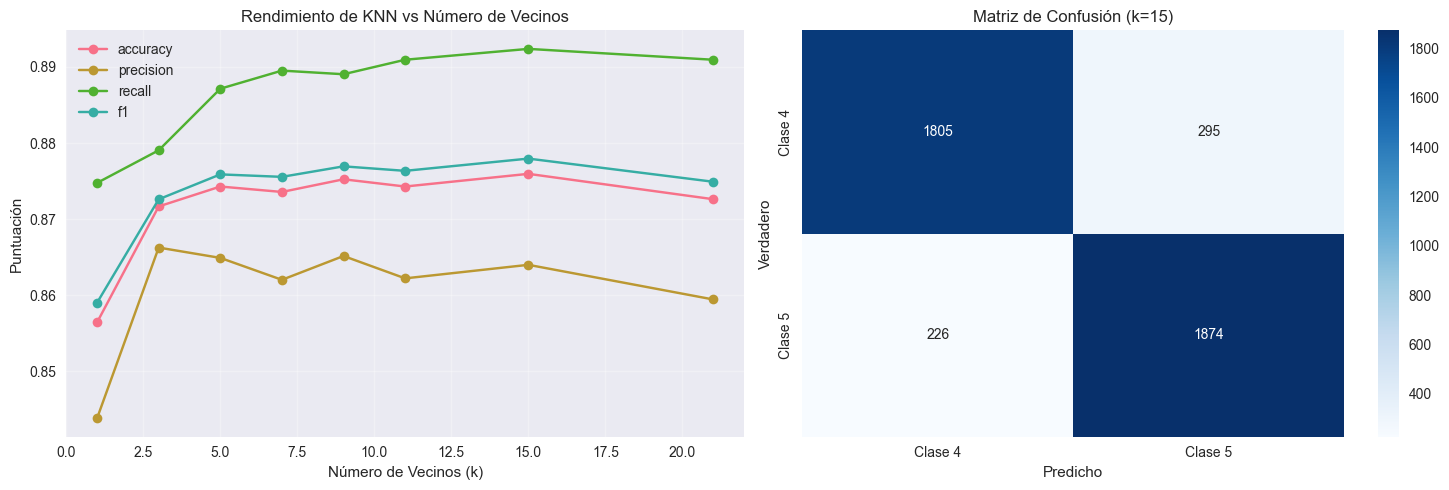


MEJOR MODELO - Reporte de Clasificación:
• Atributos: 20 (alta_varianza)
• k: 15
• Accuracy: 0.8760
• F1-Score: 0.8780

              precision    recall  f1-score   support

     Clase 4       0.89      0.86      0.87      2100
     Clase 5       0.86      0.89      0.88      2100

    accuracy                           0.88      4200
   macro avg       0.88      0.88      0.88      4200
weighted avg       0.88      0.88      0.88      4200


RESUMEN COMPARATIVO

Evolución del Accuracy por número de atributos:
•  3 atributos - Alta varianza: 0.7114, Centro: 0.6676
•  5 atributos - Alta varianza: 0.7248, Centro: 0.5295
• 10 atributos - Alta varianza: 0.8174, Centro: 0.7167
• 20 atributos - Alta varianza: 0.8743, Centro: 0.8524
• 50 atributos - Alta varianza: 0.9171, Centro: 0.9276

Evolución del F1-Score por k (con 20 atributos):
• k= 1: F1-Score = 0.8590
• k= 3: F1-Score = 0.8726
• k= 5: F1-Score = 0.8759
• k= 7: F1-Score = 0.8756
• k= 9: F1-Score = 0.8769
• k=11: F1-Score = 0.8763
•

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
import warnings
warnings.filterwarnings('ignore')

# Configuración
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Cargar y preparar datos (usando el código anterior)
carpeta = 'Archivos/'
map_caracters = pd.read_csv(carpeta + 'kuzushiji_full.csv')
class_caracters = pd.read_csv(carpeta + 'kmnist_classmap_char.csv')

list_columns = [f'pixel_{i+1}' for i in range(784)]
list_columns.append('label')
map_caracters.columns = list_columns

X = map_caracters.copy()

print("=" * 60)
print("CLASIFICACIÓN BINARIA: CLASE 4 vs CLASE 5")
print("=" * 60)

## a. CONSTRUCCIÓN DEL SUBCONJUNTO BINARIO
print("\na. CONSTRUYENDO SUBCONJUNTO BINARIO")

# Filtrar solo clases 4 y 5
clases_binarias = [4, 5]
df_binario = X[X['label'].isin(clases_binarias)].copy()

# Convertir a problema binario: clase 4 = 0, clase 5 = 1
df_binario['binary_label'] = df_binario['label'].apply(lambda x: 0 if x == 4 else 1)

X_binario = df_binario.drop(['label', 'binary_label'], axis=1)
y_binario = df_binario['binary_label']

print(f"• Total de muestras en subconjunto binario: {len(df_binario)}")
print(f"• Clase 4 (0): {sum(y_binario == 0)} muestras")
print(f"• Clase 5 (1): {sum(y_binario == 1)} muestras")
print(f"• Proporción Clase 4: {sum(y_binario == 0)/len(y_binario):.3f}")
print(f"• Proporción Clase 5: {sum(y_binario == 1)/len(y_binario):.3f}")

# Análisis de balance
balance_ratio = min(sum(y_binario == 0), sum(y_binario == 1)) / max(sum(y_binario == 0), sum(y_binario == 1))
print(f"• Ratio de balance: {balance_ratio:.3f}")

if balance_ratio > 0.8:
    print("✓ El dataset está balanceado")
else:
    print("⚠ El dataset está desbalanceado")

# Visualización del balance
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
counts = [sum(y_binario == 0), sum(y_binario == 1)]
labels = ['Clase 4', 'Clase 5']
plt.bar(labels, counts, color=['skyblue', 'lightcoral'])
plt.title('Distribución de Clases Binarias')
plt.ylabel('Número de Muestras')
for i, count in enumerate(counts):
    plt.text(i, count + 5, str(count), ha='center')

# Visualizar ejemplos de cada clase
plt.subplot(1, 2, 2)
ejemplo_clase_4 = X_binario[y_binario == 0].iloc[0].values.reshape(28, 28)
ejemplo_clase_5 = X_binario[y_binario == 1].iloc[0].values.reshape(28, 28)

plt.imshow(np.hstack([ejemplo_clase_4, np.ones((28, 5)), ejemplo_clase_5]), cmap='gray')
plt.title('Ejemplos: Clase 4 | Clase 5')
plt.axis('off')

plt.tight_layout()
plt.show()

## b. SEPARACIÓN EN TRAIN Y TEST
print("\nb. SEPARACIÓN EN CONJUNTOS DE TRAIN Y TEST")

X_train, X_test, y_train, y_test = train_test_split(
    X_binario, y_binario, 
    test_size=0.3, 
    random_state=42,
    stratify=y_binario  # Para mantener proporción de clases
)

print(f"• Conjunto de entrenamiento: {X_train.shape[0]} muestras")
print(f"• Conjunto de test: {X_test.shape[0]} muestras")
print(f"• Proporción Clase 4 en train: {sum(y_train == 0)/len(y_train):.3f}")
print(f"• Proporción Clase 5 en train: {sum(y_train == 1)/len(y_train):.3f}")

## c. SELECCIÓN DE ATRIBUTOS Y MODELO KNN
print("\nc. SELECCIÓN DE ATRIBUTOS Y MODELADO KNN")

# Análisis de varianza para selección de atributos
varianzas = X_train.var().sort_values(ascending=False)
print(f"• Varianza máxima: {varianzas.max():.4f}")
print(f"• Varianza mínima: {varianzas.min():.4f}")
print(f"• Varianza promedio: {varianzas.mean():.4f}")

# Diferentes estrategias de selección de atributos
def seleccionar_atributos(X, estrategia, n_atributos):
    if estrategia == 'alta_varianza':
        # Los n atributos con mayor varianza
        indices = X.var().nlargest(n_atributos).index
    elif estrategia == 'baja_varianza':
        # Los n atributos con menor varianza (para comparación)
        indices = X.var().nsmallest(n_atributos).index
    elif estrategia == 'distribuidos':
        # Atributos distribuidos uniformemente en la imagen
        paso = 784 // n_atributos
        indices = [f'pixel_{i+1}' for i in range(0, 784, paso)][:n_atributos]
    elif estrategia == 'centro':
        # Atributos del centro de la imagen (donde está el carácter)
        centro = 392  # pixel central (14*28 + 14)
        radio = n_atributos // 2
        indices = [f'pixel_{i+1}' for i in range(centro-radio, centro+radio)][:n_atributos]
    
    return indices

# Función para evaluar modelo
def evaluar_modelo(modelo, X_test, y_test, nombre_modelo):
    y_pred = modelo.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='binary')
    recall = recall_score(y_test, y_pred, average='binary')
    f1 = f1_score(y_test, y_pred, average='binary')
    
    print(f"\n{nombre_modelo}:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    
    return {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1, 'y_pred': y_pred}

# Prueba con diferentes cantidades de atributos
resultados = {}
n_atributos_lista = [3, 5, 10, 20, 50]

for n_atributos in n_atributos_lista:
    print(f"\n{'='*50}")
    print(f"EVALUANDO CON {n_atributos} ATRIBUTOS")
    print(f"{'='*50}")
    
    resultados[n_atributos] = {}
    
    # Probar diferentes estrategias de selección
    estrategias = ['alta_varianza', 'centro', 'distribuidos']
    
    for estrategia in estrategias:
        # Seleccionar atributos
        atributos_seleccionados = seleccionar_atributos(X_train, estrategia, n_atributos)
        
        print(f"\nEstrategia: {estrategia}")
        print(f"Atributos seleccionados: {[a.split('_')[1] for a in atributos_seleccionados]}")
        
        # Preparar datos con atributos seleccionados
        X_train_sel = X_train[atributos_seleccionados]
        X_test_sel = X_test[atributos_seleccionados]
        
        # Escalar datos
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_sel)
        X_test_scaled = scaler.transform(X_test_sel)
        
        # Entrenar modelo KNN (k=5 por defecto)
        knn = KNeighborsClassifier(n_neighbors=5)
        knn.fit(X_train_scaled, y_train)
        
        # Evaluar modelo
        nombre_modelo = f"{n_atributos}attrs_{estrategia}"
        resultados[n_atributos][estrategia] = evaluar_modelo(knn, X_test_scaled, y_test, nombre_modelo)

## d. COMPARACIÓN DE MODELOS CON DIFERENTES k Y ATRIBUTOS
print("\n" + "="*60)
print("d. COMPARACIÓN COMPLETA: DIFERENTES k Y ATRIBUTOS")
print("="*60)

# Mejor configuración de atributos basada en resultados anteriores
mejor_n_atributos = 20
mejor_estrategia = 'alta_varianza'
mejores_atributos = seleccionar_atributos(X_train, mejor_estrategia, mejor_n_atributos)

X_train_mejor = X_train[mejores_atributos]
X_test_mejor = X_test[mejores_atributos]

# Escalar datos
scaler = StandardScaler()
X_train_mejor_scaled = scaler.fit_transform(X_train_mejor)
X_test_mejor_scaled = scaler.transform(X_test_mejor)

# Probar diferentes valores de k
valores_k = [1, 3, 5, 7, 9, 11, 15, 21]
resultados_k = {}

plt.figure(figsize=(15, 5))

for k in valores_k:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_mejor_scaled, y_train)
    
    y_pred = knn.predict(X_test_mejor_scaled)
    
    resultados_k[k] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average='binary'),
        'recall': recall_score(y_test, y_pred, average='binary'),
        'f1': f1_score(y_test, y_pred, average='binary')
    }

# Gráfico de resultados por k
plt.subplot(1, 2, 1)
metricas = ['accuracy', 'precision', 'recall', 'f1']
for metrica in metricas:
    valores = [resultados_k[k][metrica] for k in valores_k]
    plt.plot(valores_k, valores, marker='o', label=metrica)

plt.xlabel('Número de Vecinos (k)')
plt.ylabel('Puntuación')
plt.title('Rendimiento de KNN vs Número de Vecinos')
plt.legend()
plt.grid(True, alpha=0.3)

# Matriz de confusión del mejor modelo
mejor_k = max(resultados_k, key=lambda k: resultados_k[k]['f1'])
print(f"\nMejor k encontrado: {mejor_k}")

knn_mejor = KNeighborsClassifier(n_neighbors=mejor_k)
knn_mejor.fit(X_train_mejor_scaled, y_train)
y_pred_mejor = knn_mejor.predict(X_test_mejor_scaled)

plt.subplot(1, 2, 2)
cm = confusion_matrix(y_test, y_pred_mejor)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Clase 4', 'Clase 5'], 
            yticklabels=['Clase 4', 'Clase 5'])
plt.title(f'Matriz de Confusión (k={mejor_k})')
plt.ylabel('Verdadero')
plt.xlabel('Predicho')

plt.tight_layout()
plt.show()

# Reporte de clasificación del mejor modelo
print(f"\nMEJOR MODELO - Reporte de Clasificación:")
print(f"• Atributos: {mejor_n_atributos} ({mejor_estrategia})")
print(f"• k: {mejor_k}")
print(f"• Accuracy: {resultados_k[mejor_k]['accuracy']:.4f}")
print(f"• F1-Score: {resultados_k[mejor_k]['f1']:.4f}")

print("\n" + classification_report(y_test, y_pred_mejor, 
                                 target_names=['Clase 4', 'Clase 5']))

# Resumen comparativo
print("\n" + "="*60)
print("RESUMEN COMPARATIVO")
print("="*60)

print("\nEvolución del Accuracy por número de atributos:")
for n_attrs in n_atributos_lista:
    acc_alta_var = resultados[n_attrs]['alta_varianza']['accuracy']
    acc_centro = resultados[n_attrs]['centro']['accuracy']
    print(f"• {n_attrs:2d} atributos - Alta varianza: {acc_alta_var:.4f}, Centro: {acc_centro:.4f}")

print(f"\nEvolución del F1-Score por k (con {mejor_n_atributos} atributos):")
for k in valores_k:
    print(f"• k={k:2d}: F1-Score = {resultados_k[k]['f1']:.4f}")

CLASIFICACIÓN MULTICLASE: 10 CLASES DE KANJI

a. SEPARACIÓN EN CONJUNTOS DE DESARROLLO Y HELD-OUT
Clases incluidas: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
• Total de muestras para multiclase: 70000
• Distribución de clases:
  - Clase 0: 7000 muestras (10.00%)
  - Clase 1: 7000 muestras (10.00%)
  - Clase 2: 7000 muestras (10.00%)
  - Clase 3: 7000 muestras (10.00%)
  - Clase 4: 7000 muestras (10.00%)
  - Clase 5: 7000 muestras (10.00%)
  - Clase 6: 7000 muestras (10.00%)
  - Clase 7: 7000 muestras (10.00%)
  - Clase 8: 7000 muestras (10.00%)
  - Clase 9: 7000 muestras (10.00%)

• Conjunto de desarrollo (dev): 56000 muestras
• Conjunto de held-out: 14000 muestras
• Proporciones mantenidas en desarrollo:
  - Clase 0: 5600 (10.00%) | Held-out: 1400 (10.00%)
  - Clase 1: 5600 (10.00%) | Held-out: 1400 (10.00%)
  - Clase 2: 5600 (10.00%) | Held-out: 1400 (10.00%)
  - Clase 3: 5600 (10.00%) | Held-out

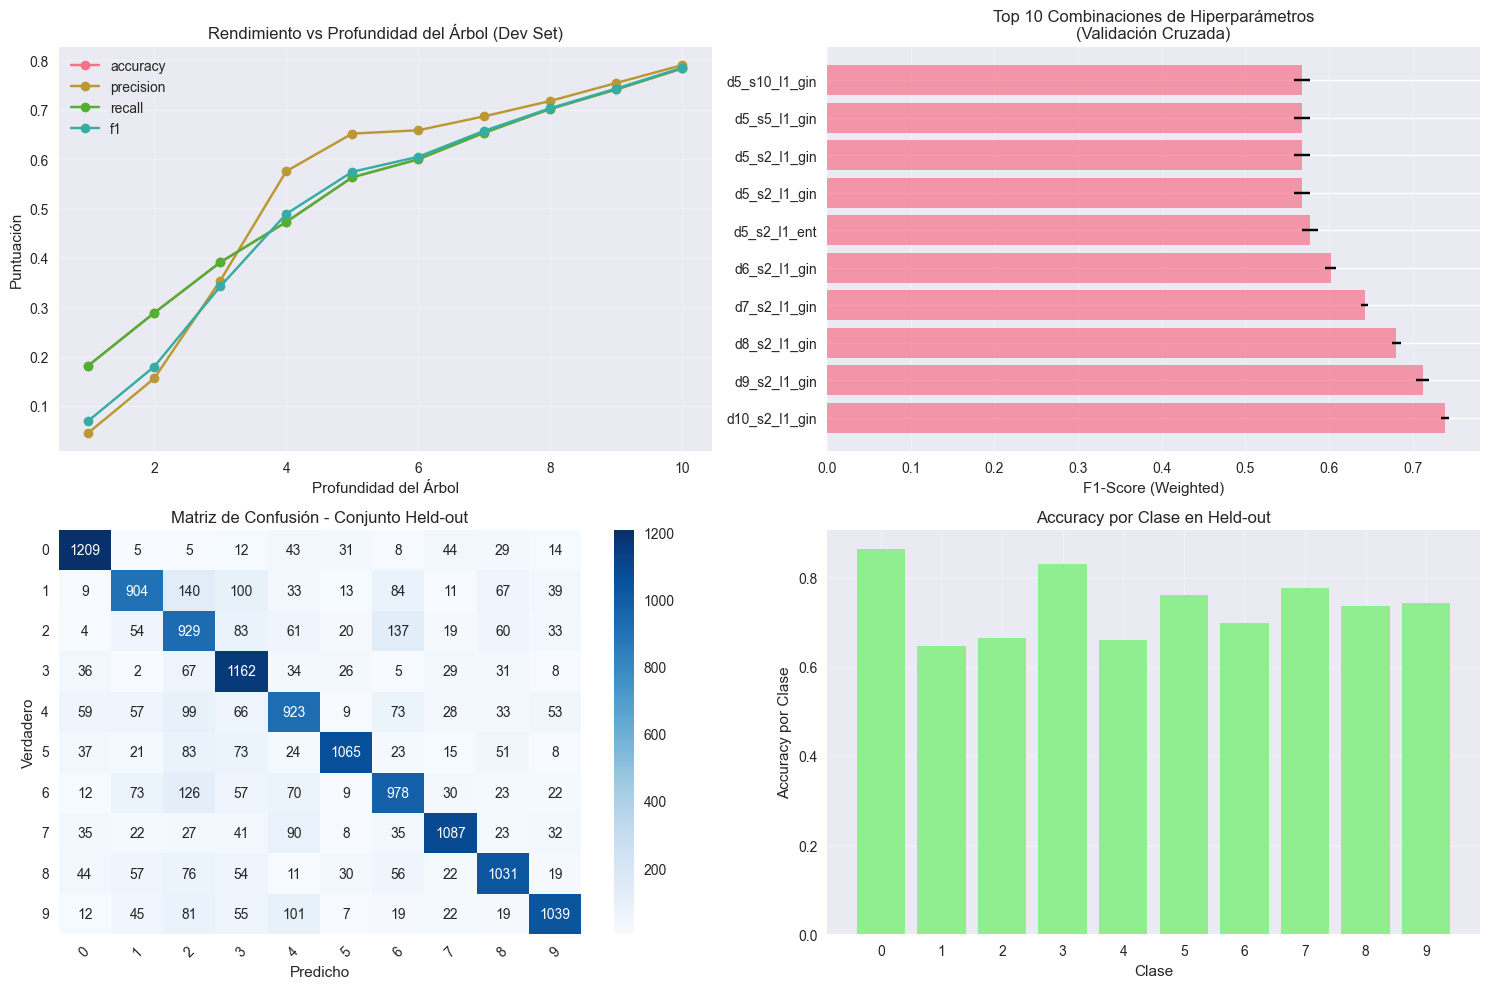


RESUMEN FINAL DEL EXPERIMENTO MULTICLASE
• Mejores hiperparámetros encontrados:
  - Profundidad máxima: 10
  - Mínimo samples split: 2
  - Mínimo samples leaf: 1
  - Criterio: gini
• Performance en desarrollo (CV): F1 = 0.7383
• Performance en held-out: F1 = 0.7390
• Diferencia desarrollo-held-out: -0.0007
✓ El modelo generaliza bien (pequeña diferencia)


In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Configuración
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Cargar y preparar datos
carpeta = 'Archivos/'
map_caracters = pd.read_csv(carpeta + 'kuzushiji_full.csv')
class_caracters = pd.read_csv(carpeta + 'kmnist_classmap_char.csv')

list_columns = [f'pixel_{i+1}' for i in range(784)]
list_columns.append('label')
map_caracters.columns = list_columns

X = map_caracters.copy()
y = X['label']
X_pixels = X.drop('label', axis=1)

print("=" * 60)
print("CLASIFICACIÓN MULTICLASE: 10 CLASES DE KANJI")
print("=" * 60)

## a. SEPARACIÓN EN DESARROLLO Y HELD-OUT
print("\na. SEPARACIÓN EN CONJUNTOS DE DESARROLLO Y HELD-OUT")

# Seleccionar solo las primeras 10 clases para el problema multiclase
clases_multiclase = sorted(y.unique())[:10]
print(f"Clases incluidas: {clases_multiclase}")

# Filtrar datos para las 10 clases
mask = y.isin(clases_multiclase)
X_filtered = X_pixels[mask]
y_filtered = y[mask]

print(f"• Total de muestras para multiclase: {len(X_filtered)}")
print(f"• Distribución de clases:")
for clase in clases_multiclase:
    count = sum(y_filtered == clase)
    print(f"  - Clase {clase}: {count} muestras ({count/len(y_filtered):.2%})")

# Separar en desarrollo (80%) y held-out (20%)
X_dev, X_heldout, y_dev, y_heldout = train_test_split(
    X_filtered, y_filtered, 
    test_size=0.2, 
    random_state=42,
    stratify=y_filtered
)

print(f"\n• Conjunto de desarrollo (dev): {X_dev.shape[0]} muestras")
print(f"• Conjunto de held-out: {X_heldout.shape[0]} muestras")
print(f"• Proporciones mantenidas en desarrollo:")

for clase in clases_multiclase:
    count_dev = sum(y_dev == clase)
    count_heldout = sum(y_heldout == clase)
    print(f"  - Clase {clase}: {count_dev} ({count_dev/len(y_dev):.2%}) | "
          f"Held-out: {count_heldout} ({count_heldout/len(y_heldout):.2%})")

## b. AJUSTE DE ÁRBOLES DE DECISIÓN CON DIFERENTES PROFUNDIDADES
print("\n" + "="*60)
print("b. AJUSTE DE ÁRBOLES DE DECISIÓN - PROFUNDIDADES 1-10")
print("="*60)

# Reducir dimensionalidad para mejor visualización (opcional)
# Usaremos PCA para visualización, pero los árboles usan todos los features
from sklearn.decomposition import PCA

pca = PCA(n_components=50)  # Reducir a 50 componentes para eficiencia
X_dev_pca = pca.fit_transform(X_dev)
X_heldout_pca = pca.transform(X_heldout)

print(f"• Varianza explicada con 50 componentes PCA: {pca.explained_variance_ratio_.sum():.3f}")

# Probar diferentes profundidades
profundidades = range(1, 11)
resultados_profundidad = {}

plt.figure(figsize=(15, 10))

# Entrenar modelos con diferentes profundidades
for i, profundidad in enumerate(profundidades):
    arbol = DecisionTreeClassifier(
        max_depth=profundidad,
        random_state=42
    )
    
    # Entrenar y predecir en conjunto de desarrollo
    arbol.fit(X_dev_pca, y_dev)
    y_pred_dev = arbol.predict(X_dev_pca)
    
    # Calcular métricas
    accuracy = accuracy_score(y_dev, y_pred_dev)
    precision = precision_score(y_dev, y_pred_dev, average='weighted')
    recall = recall_score(y_dev, y_pred_dev, average='weighted')
    f1 = f1_score(y_dev, y_pred_dev, average='weighted')
    
    resultados_profundidad[profundidad] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'model': arbol
    }
    
    print(f"Profundidad {profundidad}: "
          f"Accuracy = {accuracy:.4f}, F1 = {f1:.4f}")

# Visualizar resultados por profundidad
plt.subplot(2, 2, 1)
metricas = ['accuracy', 'precision', 'recall', 'f1']
for metrica in metricas:
    valores = [resultados_profundidad[p][metrica] for p in profundidades]
    plt.plot(profundidades, valores, marker='o', label=metrica)

plt.xlabel('Profundidad del Árbol')
plt.ylabel('Puntuación')
plt.title('Rendimiento vs Profundidad del Árbol (Dev Set)')
plt.legend()
plt.grid(True, alpha=0.3)

## c. VALIDACIÓN CRUZADA PARA SELECCIÓN DE HIPERPARÁMETROS
print("\n" + "="*60)
print("c. VALIDACIÓN CRUZADA - COMPARACIÓN DE HIPERPARÁMETROS")
print("="*60)

# Configurar validación cruzada
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Probar diferentes combinaciones de hiperparámetros
hiperparametros = {
    'max_depth': range(1, 11),
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'criterion': ['gini', 'entropy']
}

# Realizar búsqueda más sistemática
resultados_cv = []

print("Realizando validación cruzada...")
print("\nCombinaciones de hiperparámetros:")

# Probar un subconjunto de combinaciones para no sobrecargar
combinaciones_probar = [
    {'max_depth': depth, 'min_samples_split': 2, 'min_samples_leaf': 1, 'criterion': 'gini'}
    for depth in range(1, 11)
] + [
    {'max_depth': 5, 'min_samples_split': split, 'min_samples_leaf': 1, 'criterion': 'gini'}
    for split in [2, 5, 10]
] + [
    {'max_depth': 5, 'min_samples_split': 2, 'min_samples_leaf': leaf, 'criterion': 'gini'}
    for leaf in [1, 2, 5]
] + [
    {'max_depth': 5, 'min_samples_split': 2, 'min_samples_leaf': 1, 'criterion': crit}
    for crit in ['gini', 'entropy']
]

mejor_score = 0
mejores_hiperparametros = None

for params in combinaciones_probar:
    arbol = DecisionTreeClassifier(
        max_depth=params['max_depth'],
        min_samples_split=params['min_samples_split'],
        min_samples_leaf=params['min_samples_leaf'],
        criterion=params['criterion'],
        random_state=42
    )
    
    # Validación cruzada con F1-score weighted
    scores = cross_val_score(arbol, X_dev_pca, y_dev, 
                           cv=kfold, scoring='f1_weighted')
    
    score_promedio = scores.mean()
    score_std = scores.std()
    
    resultados_cv.append({
        'params': params,
        'mean_score': score_promedio,
        'std_score': score_std
    })
    
    if score_promedio > mejor_score:
        mejor_score = score_promedio
        mejores_hiperparametros = params
    
    print(f"max_depth={params['max_depth']:2d}, "
          f"min_split={params['min_samples_split']:2d}, "
          f"min_leaf={params['min_samples_leaf']:2d}, "
          f"criterion={params['criterion']:8} -> "
          f"F1 = {score_promedio:.4f} ± {score_std:.4f}")

# Mostrar mejores resultados
print(f"\n{'='*50}")
print("MEJORES HIPERPARÁMETROS ENCONTRADOS:")
print(f"{'='*50}")
print(f"• max_depth: {mejores_hiperparametros['max_depth']}")
print(f"• min_samples_split: {mejores_hiperparametros['min_samples_split']}")
print(f"• min_samples_leaf: {mejores_hiperparametros['min_samples_leaf']}")
print(f"• criterion: {mejores_hiperparametros['criterion']}")
print(f"• F1-Score promedio (CV): {mejor_score:.4f}")

# Visualizar top 10 combinaciones
resultados_cv_sorted = sorted(resultados_cv, key=lambda x: x['mean_score'], reverse=True)[:10]

plt.subplot(2, 2, 2)
nombres_combinaciones = [
    f"d{p['params']['max_depth']}_s{p['params']['min_samples_split']}_l{p['params']['min_samples_leaf']}_{p['params']['criterion'][:3]}"
    for p in resultados_cv_sorted
]
scores_means = [p['mean_score'] for p in resultados_cv_sorted]
scores_stds = [p['std_score'] for p in resultados_cv_sorted]

y_pos = np.arange(len(nombres_combinaciones))
plt.barh(y_pos, scores_means, xerr=scores_stds, alpha=0.7)
plt.yticks(y_pos, nombres_combinaciones)
plt.xlabel('F1-Score (Weighted)')
plt.title('Top 10 Combinaciones de Hiperparámetros\n(Validación Cruzada)')
plt.grid(True, alpha=0.3, axis='x')

## d. EVALUACIÓN EN CONJUNTO HELD-OUT
print("\n" + "="*60)
print("d. EVALUACIÓN FINAL EN CONJUNTO HELD-OUT")
print("="*60)

# Entrenar modelo final con mejores hiperparámetros en todo el conjunto de desarrollo
modelo_final = DecisionTreeClassifier(
    max_depth=mejores_hiperparametros['max_depth'],
    min_samples_split=mejores_hiperparametros['min_samples_split'],
    min_samples_leaf=mejores_hiperparametros['min_samples_leaf'],
    criterion=mejores_hiperparametros['criterion'],
    random_state=42
)

modelo_final.fit(X_dev_pca, y_dev)

# Predecir en conjunto held-out
y_pred_heldout = modelo_final.predict(X_heldout_pca)

# Calcular métricas finales
accuracy_heldout = accuracy_score(y_heldout, y_pred_heldout)
precision_heldout = precision_score(y_heldout, y_pred_heldout, average='weighted')
recall_heldout = recall_score(y_heldout, y_pred_heldout, average='weighted')
f1_heldout = f1_score(y_heldout, y_pred_heldout, average='weighted')

print(f"\nRESULTADOS EN CONJUNTO HELD-OUT:")
print(f"• Accuracy:  {accuracy_heldout:.4f}")
print(f"• Precision: {precision_heldout:.4f}")
print(f"• Recall:    {recall_heldout:.4f}")
print(f"• F1-Score:  {f1_heldout:.4f}")

# Matriz de confusión
plt.subplot(2, 2, 3)
cm = confusion_matrix(y_heldout, y_pred_heldout)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=clases_multiclase, 
            yticklabels=clases_multiclase)
plt.title('Matriz de Confusión - Conjunto Held-out')
plt.ylabel('Verdadero')
plt.xlabel('Predicho')
plt.xticks(rotation=45)
plt.yticks(rotation=0)

# Reporte de clasificación detallado
print("\n" + "="*50)
print("REPORTE DE CLASIFICACIÓN DETALLADO")
print("="*50)
print(classification_report(y_heldout, y_pred_heldout, 
                          target_names=[f'Clase {c}' for c in clases_multiclase]))

# Análisis de errores por clase
plt.subplot(2, 2, 4)
accuracy_por_clase = []
for clase in clases_multiclase:
    mask_clase = y_heldout == clase
    accuracy_clase = accuracy_score(y_heldout[mask_clase], y_pred_heldout[mask_clase])
    accuracy_por_clase.append(accuracy_clase)

plt.bar(range(len(clases_multiclase)), accuracy_por_clase, color='lightgreen')
plt.xticks(range(len(clases_multiclase)), clases_multiclase)
plt.xlabel('Clase')
plt.ylabel('Accuracy por Clase')
plt.title('Accuracy por Clase en Held-out')
plt.grid(True, alpha=0.3)

# Identificar clases con menor accuracy
clases_dificiles = [clases_multiclase[i] for i in range(len(clases_multiclase)) 
                   if accuracy_por_clase[i] < np.mean(accuracy_por_clase)]

print(f"\nCLASES MÁS DIFÍCILES (accuracy < promedio): {clases_dificiles}")

plt.tight_layout()
plt.show()

# Resumen final
print("\n" + "="*60)
print("RESUMEN FINAL DEL EXPERIMENTO MULTICLASE")
print("="*60)
print(f"• Mejores hiperparámetros encontrados:")
print(f"  - Profundidad máxima: {mejores_hiperparametros['max_depth']}")
print(f"  - Mínimo samples split: {mejores_hiperparametros['min_samples_split']}")
print(f"  - Mínimo samples leaf: {mejores_hiperparametros['min_samples_leaf']}")
print(f"  - Criterio: {mejores_hiperparametros['criterion']}")
print(f"• Performance en desarrollo (CV): F1 = {mejor_score:.4f}")
print(f"• Performance en held-out: F1 = {f1_heldout:.4f}")
print(f"• Diferencia desarrollo-held-out: {mejor_score - f1_heldout:.4f}")

if abs(mejor_score - f1_heldout) < 0.1:
    print("✓ El modelo generaliza bien (pequeña diferencia)")
else:
    print("⚠ Posible sobreajuste (gran diferencia entre desarrollo y held-out)")